In [1]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light

from sparcl.client import SparclClient
from astropy.convolution import convolve, Gaussian1DKernel
from astropy import units as u
from scipy.integrate import trapezoid
from specutils import Spectrum1D, SpectralRegion
from specutils.fitting import fit_lines, fit_generic_continuum
from specutils.analysis import fwhm, equivalent_width
from lmfit.models import Model, LinearModel, PolynomialModel
from lmfit.models import GaussianModel, LorentzianModel

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


plt.rcParams.update({"legend.frameon":False})

hamann_erq_path = "data/core-ERQ-stats-coords.csv"
search_log_path = "data/local/hamann-objects-desi-search-log.json"

### Data preparation

#### Load dataframes

In [2]:
hamann_data = pd.read_csv(hamann_erq_path,index_col=0)

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()

match_df = match_df.rename(columns={"best_match_id":"DESI_targetid"})

hamann_erq = hamann_data.merge(match_df,on="SDSS_id",how="left")

hamann_erq

,SDSS_id,RA,DEC,ze,i,i-W3,REW,REW_unc,FWHM,FWHM_unc,kt80,NV/CIV,BAL,UV_slope,E(B-V),E(B-V)_unc,FIRST,DESI_targetid
0,J000610.67+121501.2,1.544491,12.250354,2.31,22.1,8.0,107.0,6.0,4540.0,200.0,0.37,1.88,0,-0.20,0.66,0.01,0.0,39628078766358575
1,J000746.19+122223.9,1.942491,12.373315,2.43,21.3,4.9,220.0,6.0,2433.0,71.0,0.28,0.39,0,-0.17,0.19,0.01,0.0,39628078770555722
2,J002400.25+245031.9,6.001042,24.842208,2.81,21.6,6.0,144.0,10.0,3523.0,195.0,0.37,2.46,0,-1.14,0.20,0.02,NaN,39628365275075274
3,J004713.21+264024.7,11.805059,26.673525,2.56,20.4,4.7,101.0,2.0,3685.0,74.0,0.33,1.92,1,-1.08,0.15,0.01,NaN,Not found
4,J005044.95-021217.6,12.687326,-2.204915,2.25,21.5,4.7,147.0,9.0,4343.0,487.0,0.19,0.61,0,-1.73,0.14,0.02,0.0,39627730584601174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,J223754.52+065026.6,339.477177,6.840747,2.61,22.0,5.8,141.0,5.0,1391.0,44.0,0.36,1.03,0,-1.20,0.24,0.02,0.0,39627953214063409
93,J225438.30+232714.5,343.659621,23.454052,3.09,22.0,5.5,415.0,20.0,4412.0,146.0,0.36,0.66,0,-0.38,NaN,NaN,NaN,Not found
94,J232326.17-010033.1,350.859062,-1.009201,2.36,22.4,7.2,256.0,5.0,3989.0,62.0,0.37,2.16,0,0.91,0.40,0.01,0.0,39627766454292268
95,J232828.47+044346.8,352.118656,4.729677,2.56,21.5,5.5,359.0,5.0,1584.0,20.0,0.35,0.37,0,-0.28,0.13,0.02,0.0,39627905315113841


#### Retrieve spectra

In [3]:
client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [4]:
idxs = [int(x) for x in hamann_erq["DESI_targetid"].head(3) if x != "Not found"]

output_fields = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary','survey', 'data_release', 'targetid', 'redshift_warning', 'desi_target']

spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

In [5]:
spectra_df = pd.DataFrame(spectra.data[1:])
spectra_df

,specprimary,data_release,redshift,spectype,redshift_warning,targetid,specid,desi_target,survey,flux,wavelength,_dr
0,True,DESI-DR1,2.199301,QSO,0,39628078766358575,39628078766358575,262148,main,"[6.083261489868164, 7.300170421600342, 5.58030...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
1,True,DESI-DR1,2.837482,QSO,0,39628365275075274,39628365275075274,4611686018428305446,main,"[0.7628244161605835, -1.0635453462600708, 0.83...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
2,True,DESI-DR1,2.430429,QSO,0,39628078770555722,39628078770555722,4611686018428305446,main,"[1.2459850311279297, -3.726759195327759, -1.50...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1


### Line measurements

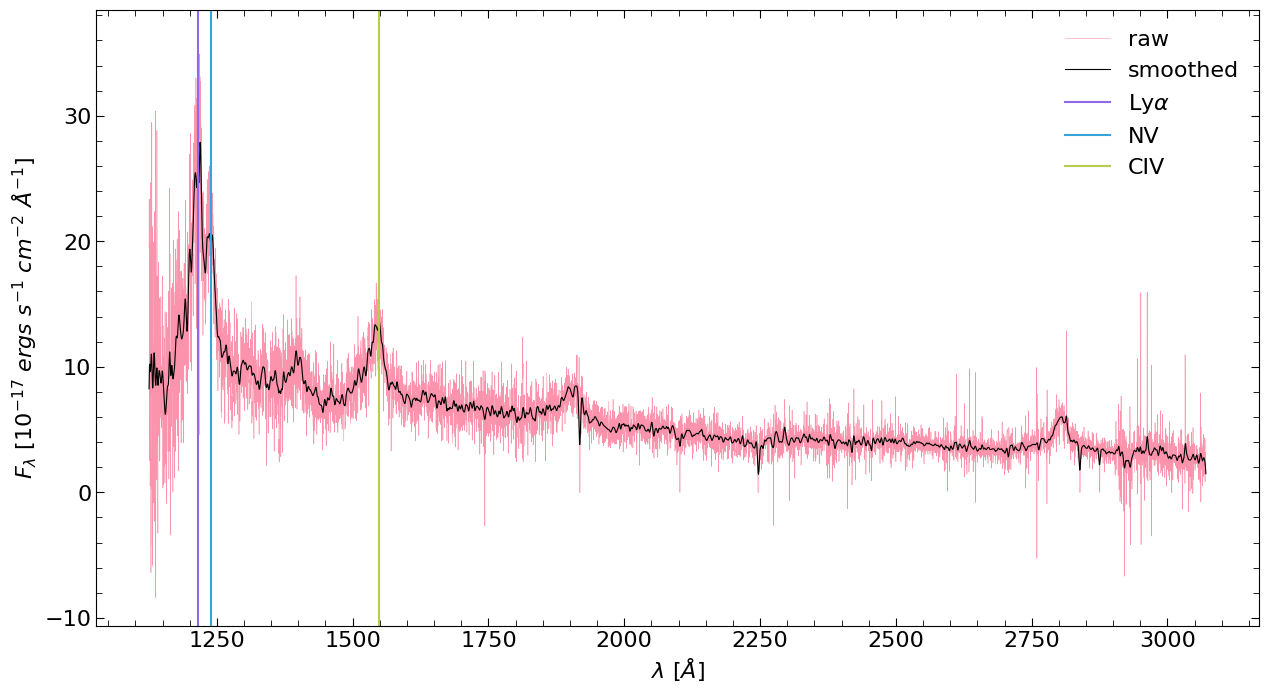

In [6]:
idx = 0

lam = np.array(spectra_df["wavelength"][idx])
flux = np.array(spectra_df["flux"][idx])
z = spectra_df["redshift"][idx]

lam, flux = adjust_redshift(lam, flux, z)

plot_spectrum(lam, flux, line_lambda=[1215,1240,1549], line_label=[r"Ly$\alpha$","NV","CIV"])

#### continuum fit w/ specutils

In [7]:
## create Spectrum1D object

flux_unit = u.erg / (u.s * u.cm**2 * u.AA)  # define unit

# components must be "Quantity" objects (hence _q suffixes), which has units
flux_q = convolve(flux, Gaussian1DKernel(5)) * flux_unit
lam_q = lam * u.AA

spec1d = Spectrum1D(flux=flux_q, spectral_axis=lam_q)

In [8]:
nv_lya_region = SpectralRegion(1150*u.AA, 1250*u.AA)
civ_region = SpectralRegion(1500*u.AA, 1600*u.AA)

continuum_fit = fit_generic_continuum(spec1d, exclude_regions=[nv_lya_region, civ_region])

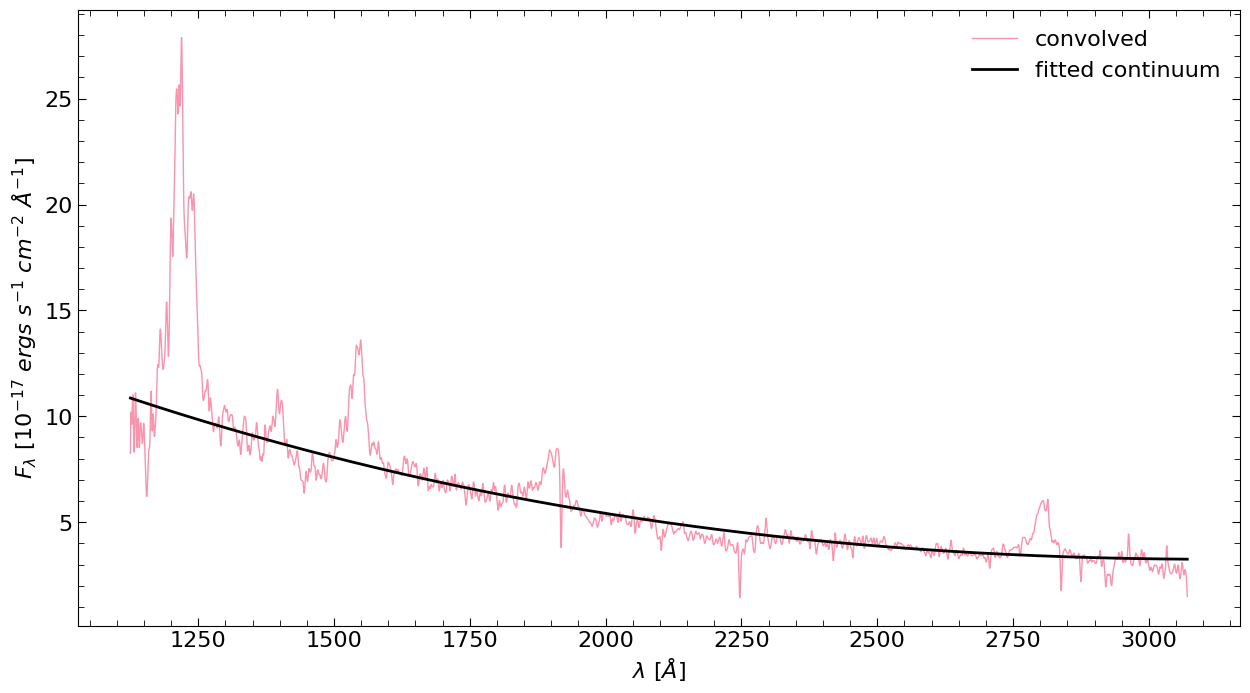

In [9]:
y_continuum_fitted = continuum_fit(lam_q)

plot_spectrum(lam_q, flux_q, additional_flux=y_continuum_fitted, additional_flux_label="fitted continuum", line_width_factor=2.5,add_smoothed=False,title="",flux_label="convolved")

In [10]:
def get_intercepts_near_line(lam, upper_flux, lower_flux, line_lambda=1549):
    '''Find two intercepting points of two fluxes that are closest to a certain x value.'''
    diffs = upper_flux - lower_flux  # calculate difference
    sign_changes = np.where(np.diff(np.sign(diffs)))  # find where sign changes to get all intercepts

    vals_at_sign_change = lam[sign_changes]  # get lambda values at intercepts

    # separate into arrays for values below and over the line
    before_line = [x for x in vals_at_sign_change if x < line_lambda]
    behind_line = [x for x in vals_at_sign_change if x > line_lambda]

    # sort lambda values by their distance to the line, then select closest each
    lower_intercept = sorted(before_line, key=lambda x: abs(x - line_lambda))[0]  
    upper_intercept = sorted(behind_line, key=lambda x: abs(x - line_lambda))[0]

    return (lower_intercept, upper_intercept)

#### line fits w/ lmfit

In [11]:
lower_lim, upper_lim = 1430,1700  # establish limits

subset_mask = (lam > lower_lim) & (lam < upper_lim )

lam_subset = lam[subset_mask]
flux_subset = flux[subset_mask]
continuum_subset = y_continuum_fitted[subset_mask]  # get only relevant subset from continuum

flux_subset = convolve(flux_subset, Gaussian1DKernel(5))

lam_subset = np.array(lam_subset)

In [50]:
gaussian1 = GaussianModel(prefix="g1_")
gaussian2 = GaussianModel(prefix="g2_")
background = LinearModel()
model = gaussian1 + gaussian2 + background

# check which params need to be specified
print('parameter names: {}'.format(model.param_names))
print('independent variables: {}'.format(model.independent_vars))

parameter names: ['g1_amplitude', 'g1_center', 'g1_sigma', 'g2_amplitude', 'g2_center', 'g2_sigma', 'slope', 'intercept']
independent variables: ['x']


In [66]:
params = model.make_params()

amplitude = max(flux_subset)
intercepts = get_intercepts_near_line(lam_subset, flux_subset, continuum_subset.value)
sigma = (intercepts[1]-intercepts[0])/2


params['g1_center'].set(value=1549)
params['g1_amplitude'].set(value=amplitude)
params['g1_sigma'].set(value=sigma/3)

params['g2_center'].set(value=1549)
params['g2_amplitude'].set(value=amplitude/2)
params['g2_sigma'].set(value=sigma)

params["slope"].set(value=0)
params["intercept"].set(value=1)

result = model.fit(flux_subset, params, x=lam_subset)

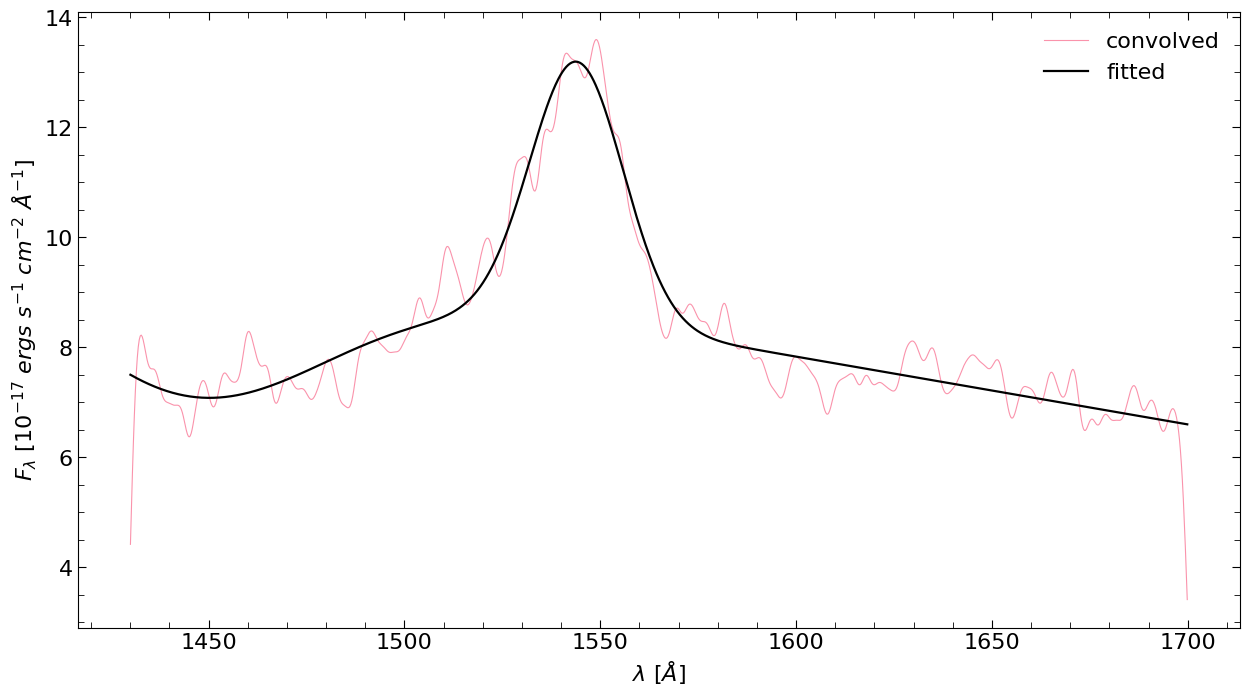

In [67]:
y_fit = result.best_fit  # extract y values from fit

# comparison of fitted spectrum with original one
plot_spectrum(lam_subset, flux_subset, title="", flux_label="convolved", add_smoothed=False, additional_flux=y_fit, additional_flux_label="fitted", line_width_factor=2)        

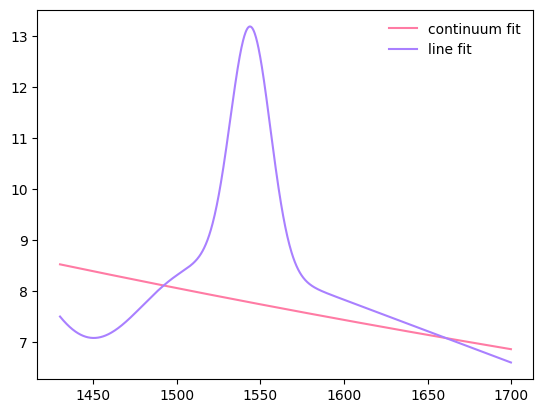

In [68]:
plt.plot(lam_subset,continuum_subset,label="continuum fit", color=palette_light[0])
plt.plot(lam_subset,y_fit,label="line fit", color=palette_light[1])

plt.legend(frameon=False)
plt.show()

In [69]:
gaussian_spec = Spectrum1D(spectral_axis=lam_subset*u.AA,flux=(y_fit-continuum_subset.value)*flux_unit)

equivalent_width(gaussian_spec,continuum=continuum_subset)
(fwhm(gaussian_spec)/1549)*2.998e5

<Quantity 5939.22963972 Angstrom>

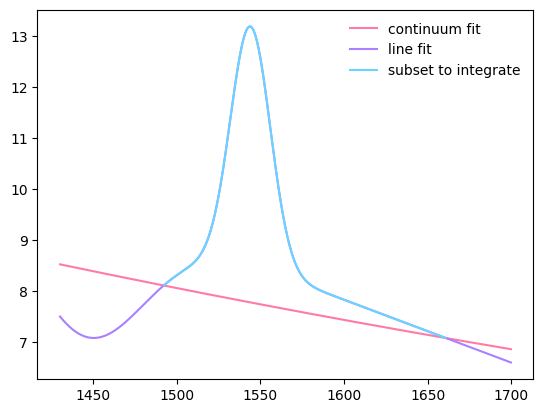

In [70]:
intercepts = get_intercepts_near_line(lam_subset, y_fit, continuum_subset.value)

flux_mask = (lam_subset > intercepts[0]) & (lam_subset < intercepts[1])

plt.plot(lam_subset,continuum_subset,label="continuum fit",color=palette_light[0])
plt.plot(lam_subset,y_fit,label="line fit",color=palette_light[1])

plt.plot(lam_subset[flux_mask],y_fit[flux_mask], color=palette_light[2], label="subset to integrate")

plt.legend(frameon=False)

plt.show()

In [71]:
trapezoid(y_fit[flux_mask],lam_subset[flux_mask])

1486.890922310442